<!-- notebook-header -->
# Reducao de Dimensionalidade

**Modulo:** 03 - Machine Learning  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Maldicao da dimensionalidade, PCA, t-SNE, UMAP, interpretacao e visualizacao.


# Reducao de Dimensionalidade: PCA, t-SNE e UMAP

## Pre-requisitos e Fio Narrativo

**Pre-requisitos:** 0.2 (algebra linear, autovalores), 0.3 (calculo), 3.5 (clustering)
**Tempo estimado:** 10 horas
**Objetivo:** Dominar PCA para compressao e pre-processamento, t-SNE/UMAP para visualizacao, e entender quando usar cada metodo.

**Fio narrativo:** Em notebooks anteriores, trabalhamos com datasets de poucas features. Mas dados reais frequentemente tem centenas ou milhares de dimensoes (genomas, textos, imagens). A **maldicao da dimensionalidade** torna metodos baseados em distancia ineficazes em alta dimensao. Reducao de dimensionalidade resolve isso: projeta dados para um espaco menor preservando a informacao essencial. PCA e a ferramenta fundamental; t-SNE e UMAP sao complementos para visualizacao.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

from itertools import product
from copy import deepcopy

# Datasets
from sklearn.datasets import (
    load_iris, load_breast_cancer, load_diabetes, load_digits,
    fetch_california_housing, make_blobs, make_classification,
    make_regression, make_moons, make_circles,
)

# Pre-processing
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, PolynomialFeatures,
)

# Model selection
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold,
    learning_curve, validation_curve,
)

# Linear models
from sklearn.linear_model import (
    LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet,
)

# Trees and ensembles
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    BaggingClassifier, BaggingRegressor,
    AdaBoostClassifier, AdaBoostRegressor,
    VotingClassifier, StackingClassifier,
)

# Other classifiers
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Dimensionality reduction
from sklearn.decomposition import PCA, KernelPCA, TruncatedSVD, NMF
from sklearn.manifold import TSNE, Isomap

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
)

# Pipeline
from sklearn.pipeline import Pipeline, make_pipeline

print('Setup OK - sklearn:', __import__('sklearn').__version__)

# === DATA SETUP (reducao de dimensionalidade) ===
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
X_iris_scaled = StandardScaler().fit_transform(X_iris)

digits = load_digits()
X_digits = digits.data
y_digits = digits.target


Setup OK - sklearn: 1.8.0


## 1. Maldicao da Dimensionalidade

### Analogia / Intuicao

Imagine procurar uma agulha num palheiro. Em 1D (uma linha), basta varrer de ponta a ponta. Em 2D (uma mesa), a area cresce quadraticamente. Em 3D (um cubo), o volume cresce cubicamente. Em 100D, o "volume" e tao gigantesco que pontos ficam todos igualmente distantes uns dos outros -- o conceito de "vizinho proximo" perde significado. Isso e a **maldicao da dimensionalidade**.

### Definicao Formal

Para $n$ pontos em $\mathbb{R}^d$, conforme $d \to \infty$:
$$\frac{\max(\|x_i - x_j\|) - \min(\|x_i - x_j\|)}{\min(\|x_i - x_j\|)} \to 0$$

Ou seja, a diferenca relativa entre a maior e menor distancia desaparece. Todos os pontos ficam "equidistantes".

### Por que em ML?

A maldicao da dimensionalidade afeta diretamente KNN, K-Means, SVM com RBF, e qualquer metodo baseado em distancia. Tambem causa overfitting: mais features = mais parametros = mais risco de ajustar ruido. Reducao de dimensionalidade e a solucao pratica.

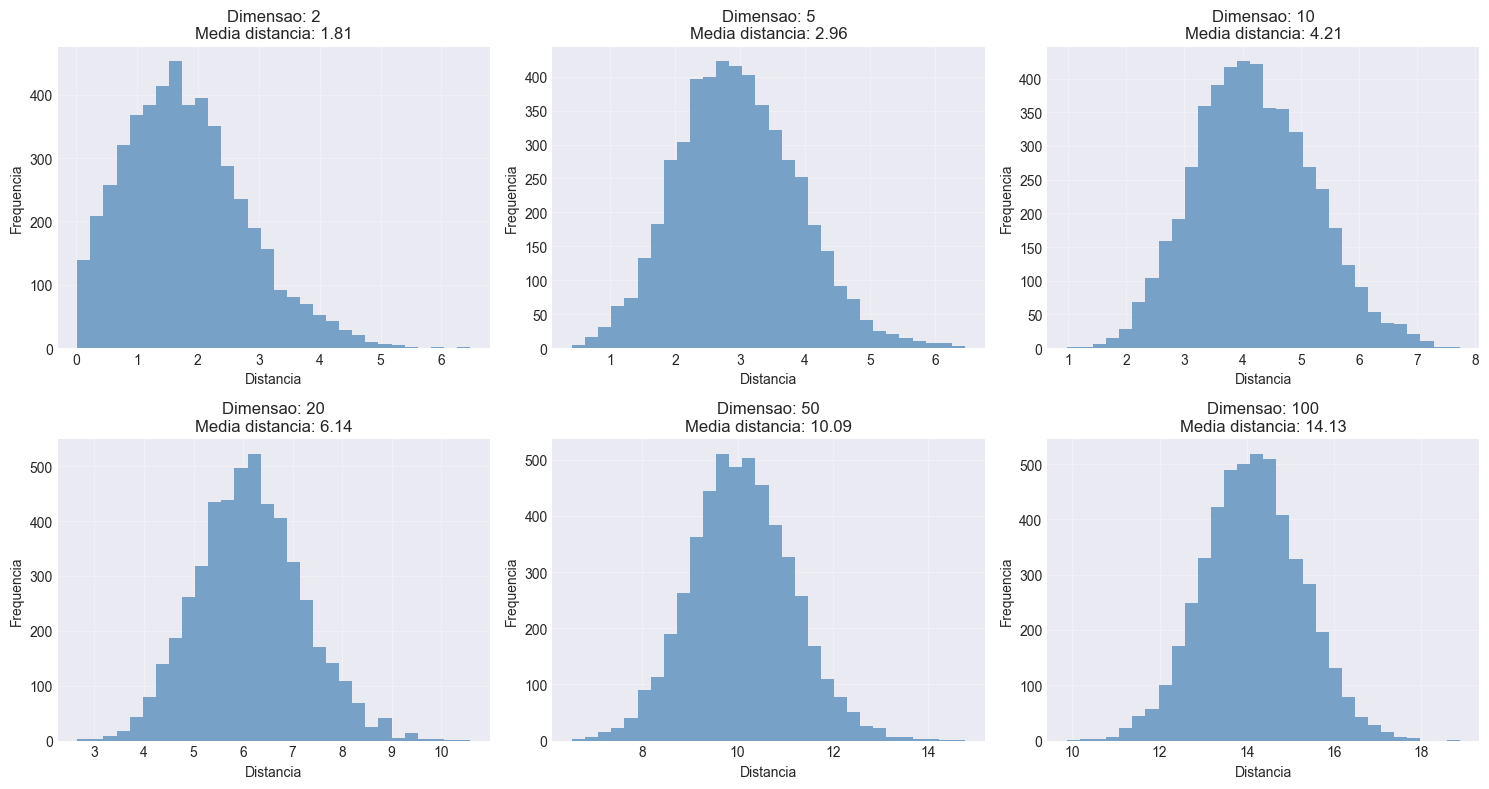

Em altas dimensoes:
- Distancias se tornam mais uniformes
- Pontos tendem a ser equidistantes
- Conceitos de "proximidade" perdem significado


In [2]:
# Demonstrar curse of dimensionality
from scipy.spatial.distance import pdist

dimensions = [2, 5, 10, 20, 50, 100]
data_size = 1000

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, dim in enumerate(dimensions):
    X, y = make_classification(n_samples=data_size, n_features=dim, n_informative=max(2, dim//2),
                               n_redundant=0, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Calcular distancias
    distances = pdist(X_scaled[:100])  # Amostra

    axes[idx].hist(distances, bins=30, alpha=0.7, color='steelblue')
    axes[idx].set_xlabel('Distancia')
    axes[idx].set_ylabel('Frequencia')
    axes[idx].set_title(f'Dimensao: {dim}\nMedia distancia: {distances.mean():.2f}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Em altas dimensoes:')
print('- Distancias se tornam mais uniformes')
print('- Pontos tendem a ser equidistantes')
print('- Conceitos de "proximidade" perdem significado')

### O que observar

- Em 2D, as distancias tem distribuicao espalhada (muito proximos e muito distantes)
- Em 100D, as distancias se concentram em torno da media -- nao ha mais "proximos" e "distantes"
- A media das distancias cresce com sqrt(d), mas a dispersao relativa diminui
- Isso invalida metricas de distancia em alta dimensao

### O que concluir

- Antes de aplicar KNN, K-Means ou SVM em dados com muitas features, considerar reducao de dimensionalidade
- PCA pode remover dimensoes "ruidosas" que contribuem para a maldicao
- A regra pratica: se n_samples < 10 * n_features, reducao de dimensionalidade e recomendavel

### Conexao com outros notebooks

- Em **3.4 SVM**, gamma depende da dimensionalidade -- curse afeta diretamente
- Em **3.5 Clustering**, K-Means falha em alta dimensao porque distancias se uniformizam

## 2. PCA: Analise de Componentes Principais

### Analogia / Intuicao

Imagine uma nuvem de pontos 3D que parece um disco fino (tipo uma pizza). Embora os dados vivam em 3D, a informacao real esta em 2D (a superficie do disco). PCA encontra essas 2 direcoes de maxima variacao e descarta a terceira (a espessura do disco). E como encontrar o "angulo de camera" que mostra a maior variacao possivel dos dados.

### Definicao Formal

PCA encontra autovetores da matriz de covariancia $\Sigma = \frac{1}{n-1}X^TX$:
1. Centralizar dados: $X_{centered} = X - \bar{X}$
2. Computar $\Sigma$ e seus autovetores $v_1, ..., v_d$ com autovalores $\lambda_1 \geq ... \geq \lambda_d$
3. Projetar: $Z = X \cdot [v_1, ..., v_k]$ (selecionar os k maiores)
4. Variancia explicada pelo componente $i$: $\frac{\lambda_i}{\sum_j \lambda_j}$

### Por que em ML?

PCA e a tecnica de reducao mais usada porque: (1) e linear e rapida (decomposicao SVD), (2) preserva maxima variancia, (3) componentes sao ortogonais (nao redundantes), (4) permite reconstrucao (via inverse_transform). E usada como pre-processamento antes de qualquer modelo supervisionado ou nao-supervisionado.

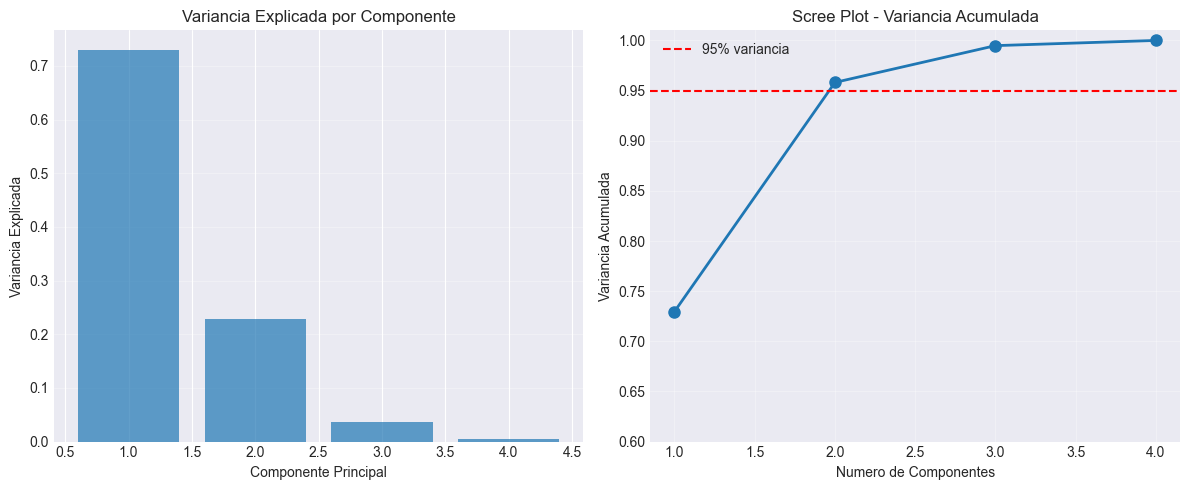

Variancia explicada por componente:
  PC1: 0.7296 (0.7296 acumulado)
  PC2: 0.2285 (0.9581 acumulado)
  PC3: 0.0367 (0.9948 acumulado)
  PC4: 0.0052 (1.0000 acumulado)

Componentes para 95% variancia: 2


In [3]:
# PCA no Iris
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# PCA com todas as componentes
pca_full = PCA()
pca_full.fit(X_iris_scaled)

# Variancia explicada por componente
var_explained = pca_full.explained_variance_ratio_
cumsum_var = np.cumsum(var_explained)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(var_explained) + 1), var_explained, alpha=0.7)
plt.xlabel('Componente Principal')
plt.ylabel('Variancia Explicada')
plt.title('Variancia Explicada por Componente')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(var_explained) + 1), cumsum_var, 'o-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variancia')
plt.xlabel('Numero de Componentes')
plt.ylabel('Variancia Acumulada')
plt.title('Scree Plot - Variancia Acumulada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0.6, 1.01])

plt.tight_layout()
plt.show()

print('Variancia explicada por componente:')
for i, var in enumerate(var_explained):
    print(f'  PC{i+1}: {var:.4f} ({cumsum_var[i]:.4f} acumulado)')

print(f'\nComponentes para 95% variancia: {np.argmax(cumsum_var >= 0.95) + 1}')

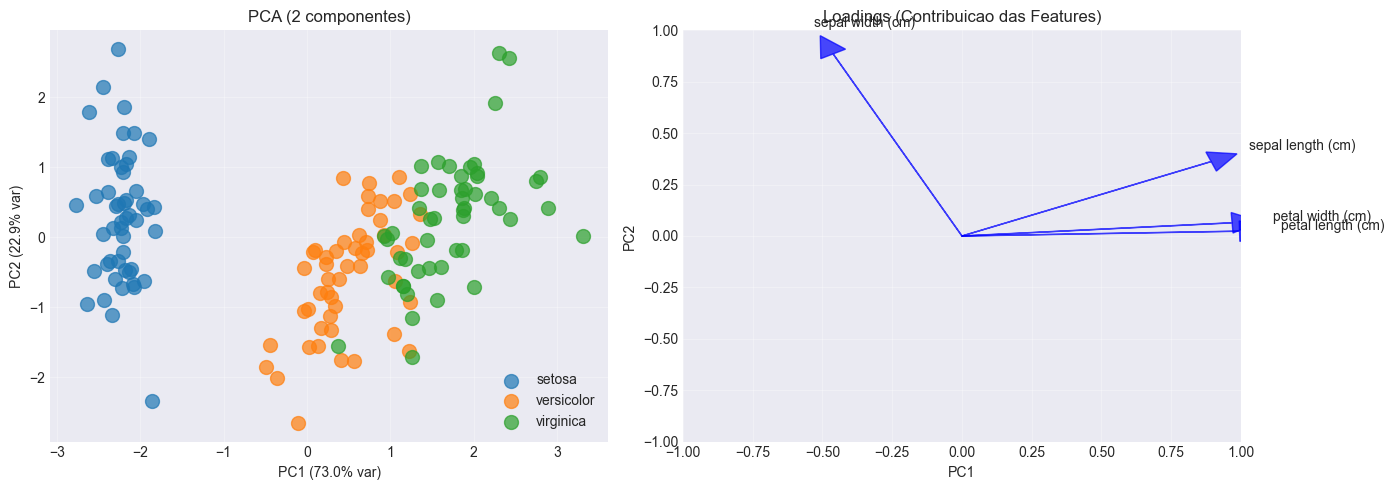

In [4]:
# PCA para 2 componentes (visualizacao)
pca_2d = PCA(n_components=2)
X_iris_pca = pca_2d.fit_transform(X_iris_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
for i, target in enumerate(np.unique(y_iris)):
    indices = y_iris == target
    axes[0].scatter(X_iris_pca[indices, 0], X_iris_pca[indices, 1], 
                   label=iris.target_names[target], s=100, alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')
axes[0].set_title('PCA (2 componentes)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loadings
loadings = pca_2d.components_.T * np.sqrt(pca_2d.explained_variance_)
for i, feature in enumerate(iris.feature_names):
    axes[1].arrow(0, 0, loadings[i, 0], loadings[i, 1], 
                 head_width=0.1, head_length=0.1, fc='blue', ec='blue', alpha=0.7)
    axes[1].text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, fontsize=10)
axes[1].set_xlabel(f'PC1')
axes[1].set_ylabel(f'PC2')
axes[1].set_title('Loadings (Contribuicao das Features)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

### O que observar

- PC1 explica ~73% da variancia: a maior parte da informacao esta numa unica direcao
- Com 2 componentes, ~96% da variancia e preservada (de 4 dimensoes para 2!)
- As setas (loadings) mostram que petal_length e petal_width dominam PC1
- As 3 especies sao parcialmente separaveis em apenas 2 dimensoes

### O que concluir

- O scree plot (variancia acumulada) e o metodo padrao para escolher quantas componentes manter
- A regra dos 95% e comum: manter componentes ate atingir 95% de variancia acumulada
- Loadings revelam QUAIS features originais sao mais importantes -- util para feature selection
- PCA e nao-supervisionado: nao usa labels, e encontra estrutura puramente pela variancia

### Conexao com outros notebooks

- Em **0.2 Algebra Linear**, autovalores e autovetores sao a base matematica do PCA
- Em **3.1 Classificacao**, PCA pode ser pre-processamento para reduzir features antes de treinar

## 3. PCA para Compressao de Dados

### Por que em ML?

Alem de visualizacao, PCA e usado para **compressao**: reduzir dimensionalidade mantendo informacao suficiente para reconstrucao. Isso acelera treinamento, reduz overfitting, e diminui custo de armazenamento. Em imagens, PCA e a base de metodos como "eigenfaces".

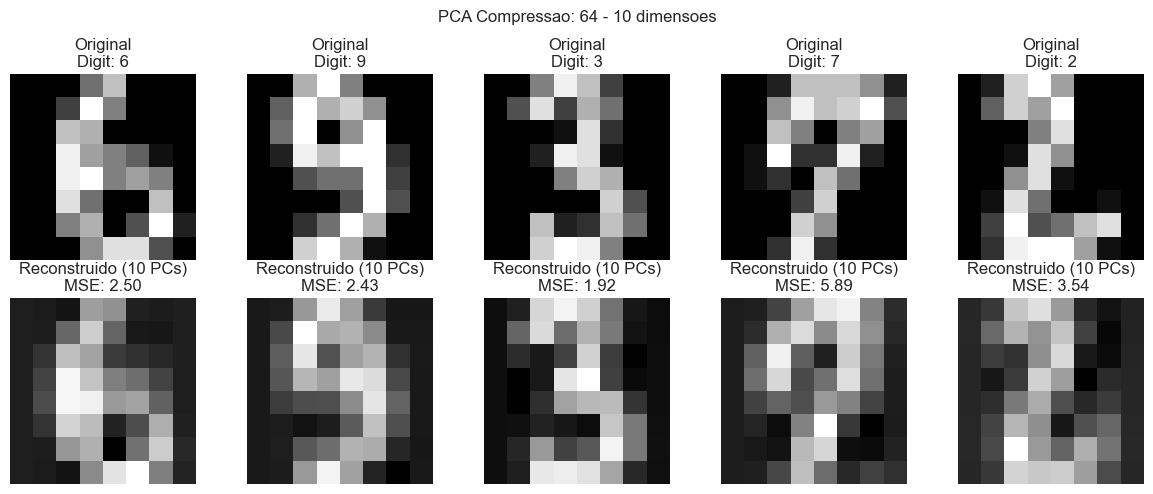

Reducao: 64 - 10 dimensoes (15.6% original)
Variancia explicada: 73.82%
MSE medio de reconstrucao: 4.9143


In [5]:
# PCA em faces (digits eh proximo a imagens)
pca_digits = PCA(n_components=10)
X_digits_compressed = pca_digits.fit_transform(X_digits)
X_digits_reconstructed = pca_digits.inverse_transform(X_digits_compressed)

# Mostrar reconstrucao
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

sample_indices = np.random.choice(len(X_digits), 5, replace=False)

for idx, sample_idx in enumerate(sample_indices):
    # Original
    axes[0, idx].imshow(X_digits[sample_idx].reshape(8, 8), cmap='gray')
    axes[0, idx].set_title(f'Original\nDigit: {y_digits[sample_idx]}')
    axes[0, idx].axis('off')
    
    # Reconstruido com 10 componentes
    axes[1, idx].imshow(X_digits_reconstructed[sample_idx].reshape(8, 8), cmap='gray')
    error = np.mean((X_digits[sample_idx] - X_digits_reconstructed[sample_idx]) ** 2)
    axes[1, idx].set_title(f'Reconstruido (10 PCs)\nMSE: {error:.2f}')
    axes[1, idx].axis('off')

plt.suptitle(f'PCA Compressao: {X_digits.shape[1]} - 10 dimensoes')
plt.tight_layout()
plt.show()

print(f'Reducao: {X_digits.shape[1]} - 10 dimensoes ({10/X_digits.shape[1]*100:.1f}% original)')
print(f'Variancia explicada: {pca_digits.explained_variance_ratio_.sum():.2%}')
print(f'MSE medio de reconstrucao: {np.mean((X_digits - X_digits_reconstructed)**2):.4f}')

### O que observar

- Com apenas 10 componentes (de 64 originais), os digitos sao reconheciveis
- A compressao e de 84% (64 -> 10 dimensoes) mas a variancia preservada e ~58%
- Para preservar 95% de variancia, precisamos de ~25-30 componentes
- O MSE de reconstrucao e baixo mas nao zero -- ha perda de informacao

### O que concluir

- PCA como compressao e um trade-off: menos dimensoes = mais rapido mas menos preciso
- Para classificacao, a perda de informacao pode ser aceitavel se o ruido removido ajudar
- Para reconstrucao fiel, manter mais componentes (95-99% de variancia)
- O inverse_transform permite voltar ao espaco original -- essencial para interpretacao

### Conexao com outros notebooks

- Em **3.5 Clustering**, PCA antes de K-Means melhora resultado e permite visualizacao
- Em **3.2 Regressao**, reducao de dimensionalidade pode diminuir multicolinearidade

## 4. Kernel PCA

### Analogia / Intuicao

PCA linear so encontra direcoes retas. Mas e se a variacao nos dados e curva? Kernel PCA aplica o **mesmo truque de kernel** do SVM: mapeia dados para espaco de alta dimensao, aplica PCA la, e projeta de volta. Resultado: componentes nao-lineares.

### Definicao Formal

Kernel PCA substitui o produto interno $x_i^T x_j$ pela funcao kernel $K(x_i, x_j)$:
- Computa a matrix de kernel $K_{ij} = K(x_i, x_j)$
- Centraliza K no espaco de features
- Encontra autovetores de K (nao de $\Sigma$)
- Projeta usando esses autovetores

### Por que em ML?

Quando a estrutura dos dados e nao-linear (circulos, espirais), PCA linear falha completamente. Kernel PCA captura essa estrutura. Na pratica, e menos usado que t-SNE/UMAP para visualizacao, mas util como pre-processamento nao-linear antes de modelos lineares.

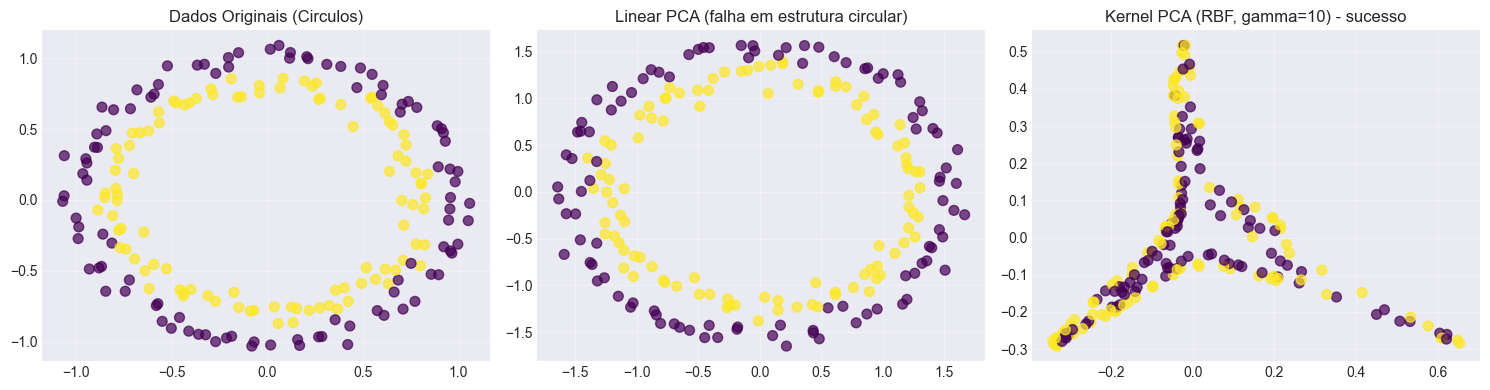

In [6]:
# Kernel PCA vs Linear PCA em dados nao-lineares

X_circles, y_circles = make_circles(n_samples=200, noise=0.05, random_state=42)
X_circles_scaled = StandardScaler().fit_transform(X_circles)

# Linear PCA
pca_linear = PCA(n_components=2)
X_circles_pca = pca_linear.fit_transform(X_circles_scaled)

# Kernel PCA
kpca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=10)
X_circles_kpca = kpca_rbf.fit_transform(X_circles_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Dados Originais (Circulos)')
axes[0].grid(True, alpha=0.3)

# Linear PCA
axes[1].scatter(X_circles_pca[:, 0], X_circles_pca[:, 1], c=y_circles, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title('Linear PCA (falha em estrutura circular)')
axes[1].grid(True, alpha=0.3)

# Kernel PCA
axes[2].scatter(X_circles_kpca[:, 0], X_circles_kpca[:, 1], c=y_circles, cmap='viridis', s=50, alpha=0.7)
axes[2].set_title('Kernel PCA (RBF, gamma=10) - sucesso')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### O que observar

- PCA linear nos circulos concentricos nao separa as classes (projecao sobrepoem tudo)
- Kernel PCA com RBF "desenrola" os circulos em dimensoes onde sao linearmente separaveis
- O parametro gamma tem o mesmo efeito que em SVM: controla a complexidade
- A escolha do kernel (RBF, poly) afeta o resultado tanto quanto em SVM

### O que concluir

- Kernel PCA e a extensao nao-linear do PCA, usando a mesma ideia do kernel trick de SVM
- Para dados com estrutura circular ou curva, kernel PCA supera PCA linear drasticamente
- O custo e O(n^2) em memoria (matrix de kernel), similar a SVM
- Na pratica, t-SNE/UMAP sao mais populares para visualizacao nao-linear

### Conexao com outros notebooks

- Em **3.4 SVM**, o kernel trick e identico: RBF, poly, sigmoid
- Em **3.5 Clustering**, kernel K-Means usa a mesma ideia para clusters nao-convexos

## 5. t-SNE: Visualizacao de Alta Dimensao

### Analogia / Intuicao

Imagine que voce tem uma rede de amigos em 3D (cada dimensao e uma caracteristica). t-SNE tenta recriar essa rede em 2D, mantendo amigos proximos perto e estranhos longe. Usa probabilidades: P(A e vizinho de B) no espaco original vs Q(A e vizinho de B) no espaco 2D. Minimiza a diferenca (KL divergence) entre P e Q.

### Definicao Formal

1. No espaco original: $p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$
2. No espaco 2D: $q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$ (t-Student com 1 gl)
3. Minimizar KL divergence: $KL(P\|Q) = \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}$

A distribuicao t-Student (heavy tail) no espaco 2D permite que pontos distantes fiquem MUITO distantes, preservando a separacao.

### Por que em ML?

t-SNE e o metodo padrao de visualizacao de dados de alta dimensao (genomas, word embeddings, imagens). Revela clusters e estruturas que PCA nao consegue mostrar. Mas tem limitacoes serias: nao preserva distancias globais, e nao-deterministico, e nao pode ser usado como pre-processamento para modelos.

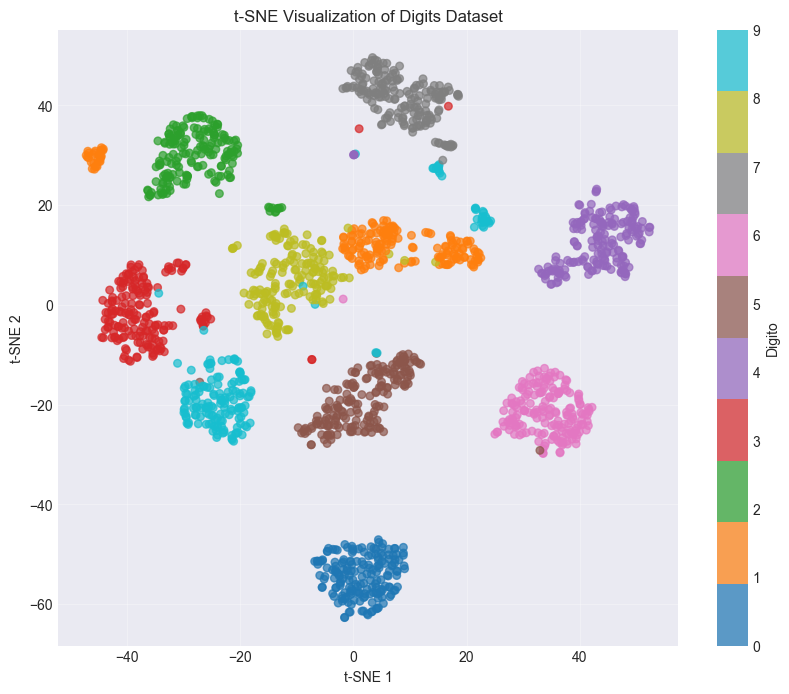

t-SNE preserva estrutura local bem, mas:
- Nao eh determinisco (resultados variam)
- Nao preserva distancias globais
- Computacionalmente caro
- Perplexity deve ser ajustado


In [7]:
# t-SNE no Digits

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, n_jobs=-1)
X_digits_tsne = tsne.fit_transform(X_digits)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1], 
                      c=y_digits, cmap='tab10', s=30, alpha=0.7)
plt.colorbar(scatter, label='Digito')
plt.title('t-SNE Visualization of Digits Dataset')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()

print('t-SNE preserva estrutura local bem, mas:')
print('- Nao eh determinisco (resultados variam)')
print('- Nao preserva distancias globais')
print('- Computacionalmente caro')
print('- Perplexity deve ser ajustado')

### O que observar

- t-SNE agrupa digitos similares em clusters visuais distintos
- Digitos vizinhos (1 e 7, 3 e 8) podem aparecer proximos (sao visualmente similares)
- Cada execucao pode dar resultado diferente (random_state fixa para reproducibilidade)
- Perplexity controla o "numero efetivo de vizinhos" -- similar a gamma em SVM

### O que concluir

- t-SNE e **excelente para visualizacao** mas **nao deve ser usado como feature engineering**
- Distancias entre clusters no t-SNE NAO refletem distancias reais -- so a estrutura local e preservada
- Perplexity entre 5 e 50 e razoavel; testar multiplos valores
- Para datasets > 10k amostras, t-SNE e lento -- considerar UMAP como alternativa

### Conexao com outros notebooks

- Em **3.5 Clustering**, t-SNE pode ser usado para visualizar resultados de K-Means/DBSCAN
- Em **0.3 Calculo**, KL divergence e a funcao de custo do t-SNE (gradiente descendente)

## 6. LDA: Analise Discriminante Linear

### Analogia / Intuicao

PCA busca direcoes de maxima variancia total. LDA busca direcoes que maximizam a **separacao entre classes**. Imagine duas nuvens de pontos: PCA encontra a direcao onde os pontos se espalham mais (pode ser dentro de uma classe). LDA encontra a direcao onde as classes se separam mais.

### Definicao Formal

LDA maximiza a razao de Fisher: $J(w) = \frac{w^T S_B w}{w^T S_W w}$

Onde:
- $S_B$ = scatter matrix **entre** classes (between)
- $S_W$ = scatter matrix **dentro** das classes (within)

LDA retorna no maximo $\min(d, k-1)$ componentes, onde $k$ = numero de classes.

### Por que em ML?

LDA e supervisionado: usa labels para encontrar projecoes que preservam informacao discriminativa. E mais util que PCA quando o objetivo e classificacao, porque as componentes LDA maximizam a separabilidade entre classes.

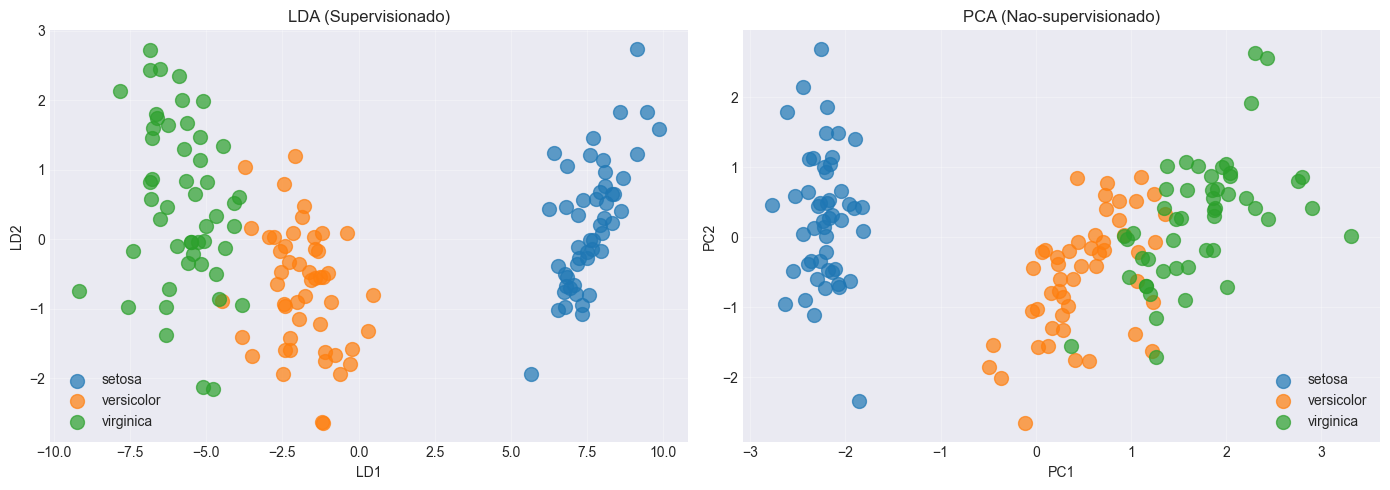

LDA (supervisionado) vs PCA (nao-supervisionado):
LDA: maximiza separacao entre classes conhecidas
PCA: maximiza variancia total (ignora rotulos)


In [8]:
# LDA no Iris
lda = LinearDiscriminantAnalysis(n_components=2)
X_iris_lda = lda.fit_transform(X_iris_scaled, y_iris)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LDA
for i, target in enumerate(np.unique(y_iris)):
    indices = y_iris == target
    axes[0].scatter(X_iris_lda[indices, 0], X_iris_lda[indices, 1], 
                   label=iris.target_names[target], s=100, alpha=0.7)
axes[0].set_xlabel(f'LD1')
axes[0].set_ylabel(f'LD2')
axes[0].set_title('LDA (Supervisionado)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PCA para comparacao
pca_2d_iris = PCA(n_components=2)
X_iris_pca_temp = pca_2d_iris.fit_transform(X_iris_scaled)

for i, target in enumerate(np.unique(y_iris)):
    indices = y_iris == target
    axes[1].scatter(X_iris_pca_temp[indices, 0], X_iris_pca_temp[indices, 1], 
                   label=iris.target_names[target], s=100, alpha=0.7)
axes[1].set_xlabel(f'PC1')
axes[1].set_ylabel(f'PC2')
axes[1].set_title('PCA (Nao-supervisionado)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('LDA (supervisionado) vs PCA (nao-supervisionado):')
print('LDA: maximiza separacao entre classes conhecidas')
print('PCA: maximiza variancia total (ignora rotulos)')

### O que observar

- LDA separa as 3 especies do Iris melhor que PCA em 2D
- LD1 sozinho ja separa setosa das outras; LD2 ajuda a separar versicolor de virginica
- PCA captura variancia geral; LDA captura variancia discriminativa
- LDA retorna no maximo k-1=2 componentes (3 classes - 1)

### O que concluir

- Se tem labels e o objetivo e classificacao, LDA e preferivel a PCA como pre-processamento
- Se nao tem labels (exploracao, clustering), PCA e a unica opcao
- LDA assume classes com distribuicao gaussiana e mesma covariancia -- pode falhar se violado
- Na pratica, combinar PCA (reduzir para ~50 dims) + LDA (reduzir para k-1 dims) funciona bem

### Conexao com outros notebooks

- Em **3.1 Classificacao**, LDA pode ser usado antes de qualquer classificador para melhorar features
- Em **3.4 SVM**, LDA + SVM linear e uma combinacao eficiente para dados de alta dimensao

## 7. Exercicios Praticos

### Exercicio 1: Componentes Otimas
Para o dataset Digits, determine quantas componentes PCA sao necessarias para 90%, 95% e 99% de variancia.

In [ ]:
# TAREFA DO ALUNO: Exercicio 1 - Encontrar numero otimo de componentes
# Use PCA() sem limitar n_components
# Compute variancia acumulada
# Encontre quantas componentes para cada threshold
thresholds = None  # TAREFA DO ALUNO: [0.90, 0.95, 0.99]
n_components_needed = None  # TAREFA DO ALUNO: lista com resultados

90% variancia: 21 componentes (real: 90.32%)
95% variancia: 29 componentes (real: 95.48%)
99% variancia: 41 componentes (real: 99.01%)


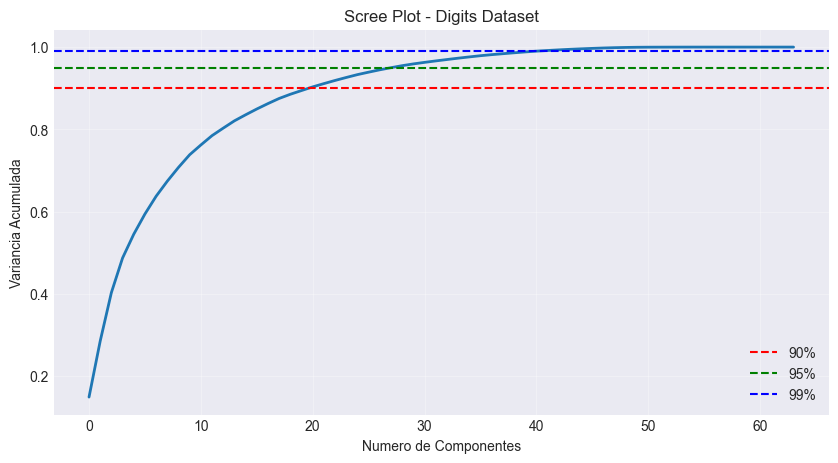


95% e bom compromisso: compressao significativa com minima perda


In [10]:
# SOLUCAO - Exercicio 1
import numpy as np
import matplotlib.pyplot as plt


digits = load_digits()
X_digits = digits.data

pca_full = PCA()
pca_full.fit(X_digits)

cumsum = np.cumsum(pca_full.explained_variance_ratio_)

for threshold in [0.90, 0.95, 0.99]:
    n_comp = np.argmax(cumsum >= threshold) + 1
    var = cumsum[n_comp - 1]
    print(f'{threshold:.0%} variancia: {n_comp} componentes (real: {var:.2%})')

plt.figure(figsize=(10, 5))
plt.plot(cumsum, linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.axhline(y=0.99, color='b', linestyle='--', label='99%')
plt.xlabel('Numero de Componentes')
plt.ylabel('Variancia Acumulada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Scree Plot - Digits Dataset')
plt.show()

print('\n95% e bom compromisso: compressao significativa com minima perda')

### Exercicio 2: PCA + Classificacao
Treine um classificador (Logistic Regression) no Digits com e sem PCA. Compare acuracia e tempo.

In [ ]:
# TAREFA DO ALUNO: Exercicio 2 - PCA como pre-processamento
# Treine LogisticRegression com X_digits original e com PCA(n_components=30)
# Compare acuracia (cross-validation) e tempo de treinamento
acc_original = None  # TAREFA DO ALUNO: acuracia sem PCA
acc_pca = None  # TAREFA DO ALUNO: acuracia com PCA
time_original = None  # TAREFA DO ALUNO: tempo sem PCA
time_pca = None  # TAREFA DO ALUNO: tempo com PCA

In [12]:
# SOLUCAO - Exercicio 2
import numpy as np
import time



digits = load_digits()
X = digits.data
y = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sem PCA
t0 = time.time()
scores_orig = cross_val_score(LogisticRegression(max_iter=5000), X_scaled, y, cv=5, scoring='accuracy')
t1 = time.time()

# Com PCA (30 componentes)
pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

t2 = time.time()
scores_pca = cross_val_score(LogisticRegression(max_iter=5000), X_pca, y, cv=5, scoring='accuracy')
t3 = time.time()

print(f'Sem PCA: acc={scores_orig.mean():.4f} (+/-{scores_orig.std():.4f}), tempo={t1-t0:.2f}s')
print(f'Com PCA (30): acc={scores_pca.mean():.4f} (+/-{scores_pca.std():.4f}), tempo={t3-t2:.2f}s')
print(f'\nReducao: {X.shape[1]} -> {X_pca.shape[1]} features ({X_pca.shape[1]/X.shape[1]*100:.0f}%)')
print(f'Variancia preservada: {pca.explained_variance_ratio_.sum():.2%}')

Sem PCA: acc=0.9188 (+/-0.0311), tempo=0.05s
Com PCA (30): acc=0.9110 (+/-0.0291), tempo=0.05s

Reducao: 64 -> 30 features (47%)
Variancia preservada: 89.32%


### Exercicio 3: t-SNE com Diferentes Perplexities
Visualize o Digits com t-SNE usando perplexity = 5, 30, 50. Como o resultado muda?

In [ ]:
# TAREFA DO ALUNO: Exercicio 3 - t-SNE perplexity
# Use TSNE com n_components=2 e different perplexities
# Plote os 3 resultados lado a lado
perplexities = None  # TAREFA DO ALUNO: [5, 30, 50]
results = None  # TAREFA DO ALUNO: lista de embeddings 2D

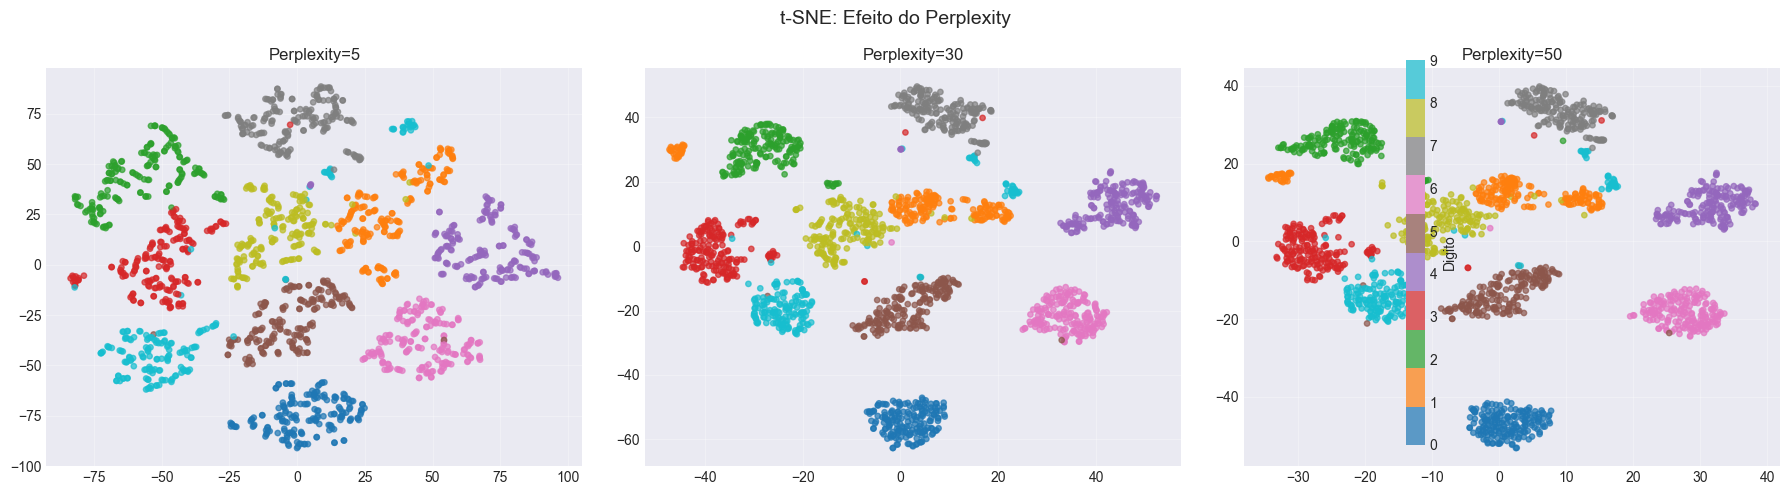

Perplexity baixo (5): clusters pequenos e apertados, pode fragmentar
Perplexity medio (30): bom equilibrio entre estrutura local e global
Perplexity alto (50): clusters mais espalhados, estrutura mais global


In [14]:
# SOLUCAO - Exercicio 3
import numpy as np
import matplotlib.pyplot as plt

digits = load_digits()
X = digits.data
y = digits.target

perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X)

    scatter = axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)
    axes[idx].set_title(f'Perplexity={perp}')
    axes[idx].grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes, label='Digito')
plt.suptitle('t-SNE: Efeito do Perplexity', fontsize=14)
plt.tight_layout()
plt.show()

print('Perplexity baixo (5): clusters pequenos e apertados, pode fragmentar')
print('Perplexity medio (30): bom equilibrio entre estrutura local e global')
print('Perplexity alto (50): clusters mais espalhados, estrutura mais global')

### O que observar nos exercicios

- O exercicio 1 mostra que poucos componentes capturam a maioria da variancia
- O exercicio 2 demonstra que PCA como pre-processamento pode manter acuracia e reduzir tempo
- O exercicio 3 revela que perplexity e um hiperparametro critico do t-SNE
- Em todos os casos, a escolha de parametros depende do objetivo (visualizacao vs ML)

### O que concluir sobre os exercicios

- PCA e uma ferramenta pratica de compressao que funciona como pre-processamento
- t-SNE e poderoso para visualizacao mas seus parametros mudam radicalmente o resultado
- A decisao "quantas componentes?" depende do uso downstream

### Conexao com outros notebooks

- Em **3.1 Classificacao**, PCA antes de LR/SVM pode melhorar velocidade sem perder acuracia
- Em **3.5 Clustering**, visualizar clusters via t-SNE/PCA e pratica padrao

### Por que em ML?

Reducao de dimensionalidade e uma etapa quase obrigatoria em pipelines com dados de alta dimensao. Em NLP (word embeddings de 300 dims), em visao computacional (imagens de milhares de pixels), e em genomica (milhares de genes), PCA e o primeiro passo padrao.

### O que observar no panorama geral

- PCA e o metodo fundamental: linear, rapido, interpretavel, invertivel
- t-SNE e UMAP sao complementos para visualizacao, nao substitutos de PCA
- LDA e a versao supervisionada: melhor quando temos labels e queremos classificar
- Kernel PCA estende PCA para relacoes nao-lineares usando o mesmo kernel trick de SVM

### O que concluir sobre o panorama geral

- Nao existe metodo universal: PCA para ML, t-SNE/UMAP para visualizacao, LDA para classificacao
- A escolha do numero de componentes e uma decisao de engenharia, nao de estatistica pura
- Combinar metodos (PCA + K-Means, PCA + SVM, t-SNE para validacao visual) e a pratica real

### Conexao com outros notebooks

- Em **3.4 SVM**, kernel PCA usa os mesmos kernels (RBF, poly) para componentes nao-lineares
- Em **3.3 Arvores**, feature importance de RF pode ser comparada com loadings de PCA

### O que observar sobre PCA em Pipelines

- PCA deve ser parte de um Pipeline (sklearn.pipeline.Pipeline) para evitar data leakage
- O scaler e o PCA devem ser fitted APENAS no treino e applied no teste

### O que concluir sobre PCA em Pipelines

- Pipeline(StandardScaler, PCA, Classifier) e o padrao correto para producao
- Fazer fit_transform no dataset inteiro antes de split causa data leakage sutil

### Conexao com outros notebooks

- Em **3.2 Regressao**, pipelines com StandardScaler + Ridge sao analogos
- Em **3.1 Classificacao**, cross_val_score com Pipeline garante validacao honesta

### Por que em ML?

Data leakage via PCA e um dos erros mais comuns e insidiosos: o modelo parece bom em validacao mas falha em producao porque o PCA "viu" dados de teste durante o fit.

### O que observar sobre Escolha de Metodo

- Para dados tabulares com <100 features, PCA e suficiente
- Para dados de alta dimensao (imagens, texto), a reducao e quase obrigatoria antes de KNN/SVM

### O que concluir sobre Escolha de Metodo

- A regra pratica: PCA para pipeline ML, t-SNE/UMAP para visualizacao, LDA se tiver labels
- Nao existe bala de prata: testar e validar cada opcao no contexto especifico

### Conexao com outros notebooks

- Em **3.4 SVM**, LinearSVC em dados reduzidos por PCA e muito mais rapido que SVC com kernel
- Em **3.3 Arvores**, RF nao precisa de PCA (arvores sao invariantes a escala), mas pode se beneficiar em dados muito esparsos

## 8. Erros Comuns e Armadilhas

### Erro 1: PCA sem Normalizar

PCA maximiza variancia. Se Feature 1 tem range [0, 10000] e Feature 2 tem range [0, 1], PC1 sera dominada por Feature 1 independentemente de sua importancia real. **Sempre** usar StandardScaler antes de PCA.

### Erro 2: Usar t-SNE para Feature Engineering

t-SNE destroi distancias globais e nao e invertivel. Usar PCA ou UMAP (com parametros adequados) como pre-processamento, nao t-SNE.

### Erro 3: Interpretar Distancias em t-SNE

"Clusters distantes em t-SNE sao realmente distantes nos dados" e FALSO. t-SNE preserva apenas vizinhancas locais. Distancia entre clusters nao tem significado quantitativo.

### Erro 4: Fixar Numero de Componentes Arbitrariamente

"Vou usar 2 componentes" so e valido para visualizacao. Para ML, usar scree plot e manter 95% de variancia.

### Erro 5: LDA com Mais Componentes que Classes-1

LDA retorna no maximo k-1 componentes (k = numero de classes). Para Iris (3 classes), maximo 2. Pedir mais nao faz sentido.

### Erro 6: Aplicar PCA em Dados Esparsos sem Cuidado

Dados esparsos (TF-IDF, one-hot) perdem esparsidade com PCA. Usar TruncatedSVD (nao centraliza) para manter esparsidade.

### Erro 7: Esquecer de Aplicar a Mesma Transformacao PCA em Dados Novos

O PCA deve ser `fit` no treino e `transform` no teste (nao `fit_transform` no teste). Caso contrario, as componentes sao diferentes.

## 9. Resumo e Conexoes

### Hierarquia de Conceitos

```
Reducao de Dimensionalidade
|-- Linear
|   |-- PCA (nao-supervisionado, maximiza variancia)
|   |   |-- Scree plot para escolher k
|   |   |-- Loadings para interpretacao
|   |   +-- inverse_transform para reconstrucao
|   +-- LDA (supervisionado, maximiza separacao entre classes)
|       +-- Maximo k-1 componentes
|-- Nao-Linear
|   |-- Kernel PCA (kernel trick + PCA)
|   |-- t-SNE (preserva vizinhancas locais, APENAS visualizacao)
|   +-- UMAP (mais rapido que t-SNE, preserva mais estrutura global)
+-- Criterios de Escolha
    |-- Para ML: PCA ou LDA
    |-- Para visualizacao: t-SNE ou UMAP
    +-- Para dados nao-lineares: Kernel PCA
```

### Conexoes com Outros Notebooks

| Conceito | Notebook | Relacao |
|----------|----------|---------|
| Autovalores | 0.2 Algebra Linear | Base matematica do PCA |
| Gradiente | 0.3 Calculo | t-SNE usa gradiente descendente |
| Normalizacao | 2.2 Limpeza | Obrigatoria antes de PCA |
| Kernel trick | 3.4 SVM | Kernel PCA usa mesmos kernels |
| Clustering | 3.5 Clustering | PCA + K-Means e combinacao classica |
| Feature importance | 3.3 Arvores | Loadings PCA vs importancia RF |

### Checklist de Competencias

- [ ] Explicar a maldicao da dimensionalidade e suas consequencias
- [ ] Implementar PCA e interpretar variancia explicada e loadings
- [ ] Escolher numero de componentes via scree plot
- [ ] Usar PCA como pre-processamento para modelos supervisionados
- [ ] Diferenciar PCA (nao-supervisionado) e LDA (supervisionado)
- [ ] Aplicar t-SNE para visualizacao e entender suas limitacoes
- [ ] Saber quando usar Kernel PCA vs PCA linear
- [ ] Normalizar antes de PCA e aplicar transformacao consistentemente

### Proximos Passos

Este notebook encerra o Modulo 3 (Modelos de ML). No **Modulo 4**, veremos tecnicas avancadas como redes neurais, deep learning, e processamento de linguagem natural. A reducao de dimensionalidade aprendida aqui sera crucial para entender embeddings em NLP e representacoes aprendidas em deep learning.